# 📊 Análisis Descriptivo de Datos

## 🎯 Introducción

El **Análisis Descriptivo** es el proceso de responder preguntas de negocio específicas mediante técnicas estadísticas y visualizaciones. A diferencia del EDA (exploración general), el análisis descriptivo se enfoca en:

- ❓ **Responder preguntas concretas** sobre los datos
- 📈 **Calcular estadísticos relevantes** (promedios, tendencias, proporciones)
- 📊 **Crear visualizaciones orientadas a insights** específicos
- 💡 **Generar conclusiones accionables** para toma de decisiones
- 🎯 **Comunicar hallazgos** de forma clara y efectiva

**En este notebook** realizaremos un análisis descriptivo completo del dataset de transporte público CTA Chicago, respondiendo **5 preguntas clave** que tienen implicaciones prácticas para la gestión y planificación del servicio.

## 📑 Contenido del notebook:

### **⚙️ Configuración y Preprocesamiento**
- Configuración SSL para VS Code
- Carga del dataset
- Limpieza básica
- Ingeniería de características temporales

### **📅 1. Patrones Estacionales y Tendencias Anuales**
- **Pregunta**: ¿Existen patrones estacionales o diferencias significativas entre años?
- **Utilidad**: Planificación de recursos según temporada, detección de crecimientos/caídas

### **🚌 2. Bus vs Tren: Evolución de Preferencias**
- **Pregunta**: ¿Cómo varía la proporción de usuarios de bus vs tren?
- **Utilidad**: Decisiones de inversión y mantenimiento por tipo de transporte

### **📆 3. Análisis por Día de la Semana**
- **Pregunta**: ¿Qué días tienen mayor/menor volumen de pasajeros?
- **Utilidad**: Optimizar frecuencias y gestión de personal por día

### **🦠 4. Impacto de COVID-19**
- **Pregunta**: ¿Cómo impactó la pandemia y se ha recuperado la demanda?
- **Utilidad**: Evaluar necesidad de estrategias de recuperación

### **📈 5. Tendencias Generales con Medias Móviles**
- **Pregunta**: ¿Qué tendencia sigue el uso del transporte público?
- **Utilidad**: Monitorización de cambios a largo plazo

---

## 💼 Valor del Análisis Descriptivo

Este tipo de análisis es fundamental para:
- ✅ Fundamentar decisiones operativas con datos
- ✅ Identificar oportunidades de mejora
- ✅ Detectar problemas antes de que se agraven
- ✅ Comunicar insights a stakeholders no técnicos
- ✅ Justificar inversiones y cambios estratégicos

## ⚙️ Configuración y Preprocesamiento

In [1]:
# ⚠️ IMPORTANTE: Si ejecutas este notebook en VS Code (no en Google Colab),
# descomenta estas líneas para evitar errores de certificado SSL:

# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

print("✅ Configuración lista")

✅ Configuración lista


In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("📥 Cargando dataset de transporte CTA Chicago...")

# Cargar el dataset desde GitHub
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(url, parse_dates=["service_date"])

print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

# --- PREPROCESAMIENTO E INGENIERÍA DE CARACTERÍSTICAS ---

# 1. Eliminar duplicados
df = df.drop_duplicates()
print(f"🔹 Duplicados eliminados. Filas resultantes: {df.shape[0]}")

# 2. Establecer fecha como índice y ordenar
df = df.set_index("service_date").sort_index()
print(f"🔹 Índice establecido en 'service_date'")

# 3. Crear variables temporales derivadas
df["day_of_week"] = df.index.day_name()
df["year"] = df.index.year
df["month"] = df.index.month
print(f"🔹 Variables temporales creadas: day_of_week, year, month")

# 4. Lista de días de la semana ordenados (útil para visualizaciones)
dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

print("\n🎉 Preprocesamiento completado. Dataset listo para análisis.")

📥 Cargando dataset de transporte CTA Chicago...
✅ Dataset cargado: 8036 filas, 5 columnas
🔹 Duplicados eliminados. Filas resultantes: 7974
🔹 Índice establecido en 'service_date'
🔹 Variables temporales creadas: day_of_week, year, month

🎉 Preprocesamiento completado. Dataset listo para análisis.


# 📅 1. Patrones Estacionales y Tendencias Anuales

## ❓ Pregunta de Análisis

¿Existen **patrones estacionales** o **diferencias significativas entre años** en el número promedio de pasajeros por mes?

## 💼 Utilidad para el Negocio

- **Planificación de recursos**: Ajustar vehículos y personal según temporada
- **Detección de tendencias**: Identificar crecimientos o caídas año tras año
- **Presupuestación**: Anticipar ingresos y costos por estacionalidad
- **Estrategias de marketing**: Campañas en meses de baja demanda

<Figure size 1400x800 with 0 Axes>

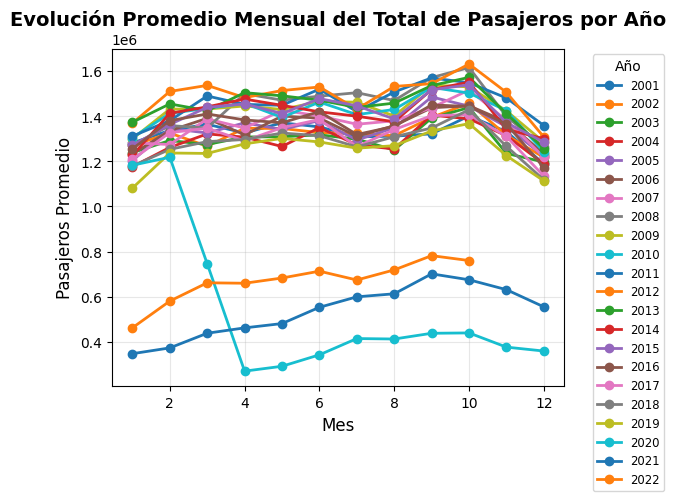

💡 Observación: El gráfico está muy sobrecargado con tantos años.
   🔹 A continuación lo desglosaremos por períodos de 5 años para mayor claridad.


In [3]:
# Calcular promedio mensual por año
monthly_avg = df.groupby(["year", "month"])["total_rides"].mean().unstack(level=0)

# Gráfico con todos los años (vista general)
plt.figure(figsize=(14, 8))
monthly_avg.plot(marker='o', linewidth=2)
plt.title("Evolución Promedio Mensual del Total de Pasajeros por Año", fontsize=14, fontweight='bold')
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Pasajeros Promedio", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="Año", fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("💡 Observación: El gráfico está muy sobrecargado con tantos años.")
print("   🔹 A continuación lo desglosaremos por períodos de 5 años para mayor claridad.")

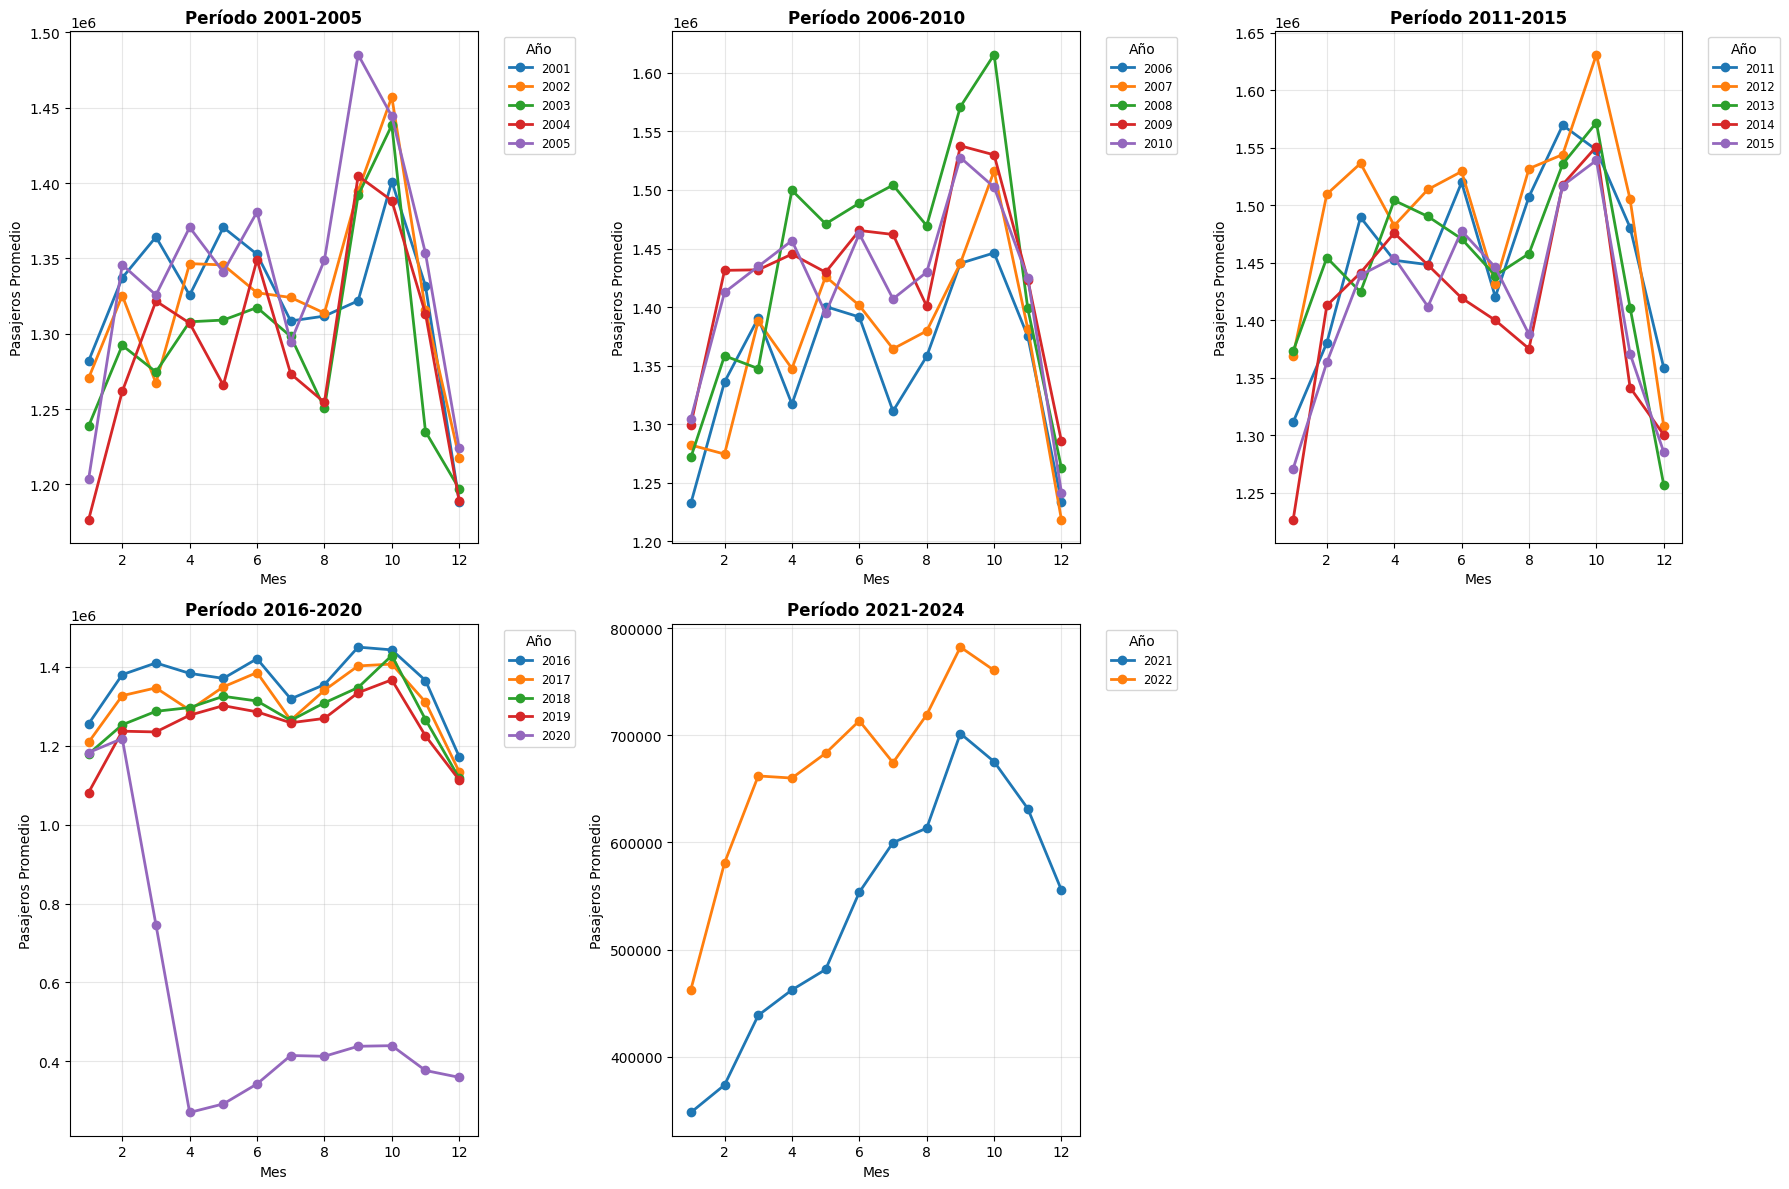

💡 Hallazgos clave:
  🔹 Patrones estacionales: Ligera caída en febrero, picos variables por año
  🔹 2001-2015: Relativa estabilidad con crecimiento gradual
  🔹 2016-2020: Caída drástica en 2020 (COVID-19)
  🔹 2021-2024: Recuperación parcial, sin alcanzar niveles pre-pandemia


In [4]:
# Desglosar por períodos de 5 años para mejor visualización
year_ranges = [(2001, 2005), (2006, 2010), (2011, 2015), (2016, 2020), (2021, 2024)]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, (start_year, end_year) in enumerate(year_ranges):
    ax = axes[i]
    # Filtrar años del período actual
    years_to_plot = [year for year in monthly_avg.columns if start_year <= year <= end_year]
    monthly_avg[years_to_plot].plot(marker='o', ax=ax, linewidth=2)
    ax.set_title(f"Período {start_year}-{end_year}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Mes")
    ax.set_ylabel("Pasajeros Promedio")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Año", fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ocultar el subplot vacío (posición 6)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("💡 Hallazgos clave:")
print("  🔹 Patrones estacionales: Ligera caída en febrero, picos variables por año")
print("  🔹 2001-2015: Relativa estabilidad con crecimiento gradual")
print("  🔹 2016-2020: Caída drástica en 2020 (COVID-19)")
print("  🔹 2021-2024: Recuperación parcial, sin alcanzar niveles pre-pandemia")

# 🚌 2. Bus vs Tren: Evolución de Preferencias

## ❓ Pregunta de Análisis

¿Cómo varía a lo largo del tiempo la **proporción de pasajeros** que utilizan el autobús frente al tren? ¿Existen **cambios estructurales** en las preferencias de los usuarios?

## 💼 Utilidad para el Negocio

- **Decisiones de inversión**: Priorizar recursos según modo de transporte más usado
- **Mantenimiento estratégico**: Planificar renovación de flotas según demanda
- **Marketing diferenciado**: Campañas específicas para bus o tren
- **Detección de cambios**: Identificar si eventos externos afectan preferencias

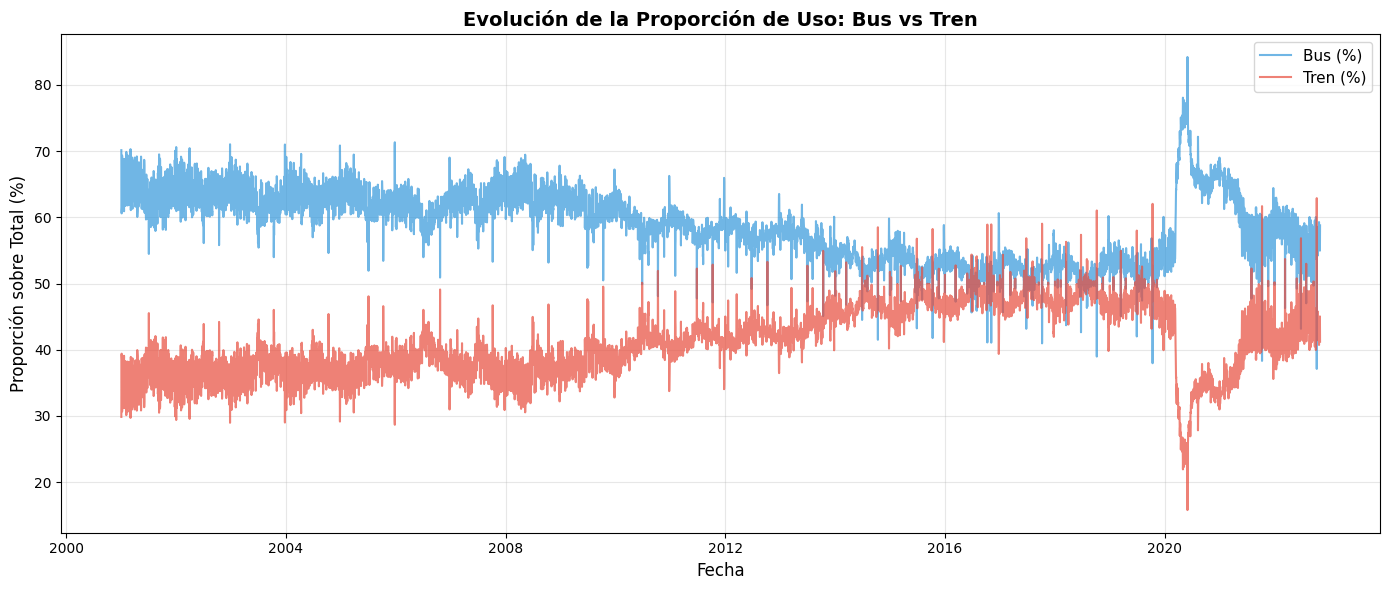

💡 Hallazgos clave:
  🔹 Bus: Representa aproximadamente 60-65% del total de pasajeros
  🔹 Tren: Representa aproximadamente 35-40% del total
  🔹 Proporciones relativamente estables a lo largo del tiempo
  🔹 Pequeñas fluctuaciones probablemente asociadas a eventos externos


In [5]:
# Calcular proporciones relativas de bus y tren sobre el total
transport_df = df[["bus", "rail_boardings", "total_rides"]].copy()
transport_df["bus_pct"] = (df["bus"] / df["total_rides"]) * 100
transport_df["rail_pct"] = (df["rail_boardings"] / df["total_rides"]) * 100

# Visualizar evolución de proporciones
plt.figure(figsize=(14, 6))
plt.plot(transport_df.index, transport_df["bus_pct"], label="Bus (%)", alpha=0.7, linewidth=1.5, color='#3498db')
plt.plot(transport_df.index, transport_df["rail_pct"], label="Tren (%)", alpha=0.7, linewidth=1.5, color='#e74c3c')
plt.title("Evolución de la Proporción de Uso: Bus vs Tren", fontsize=14, fontweight='bold')
plt.ylabel("Proporción sobre Total (%)", fontsize=12)
plt.xlabel("Fecha", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Hallazgos clave:")
print("  🔹 Bus: Representa aproximadamente 60-65% del total de pasajeros")
print("  🔹 Tren: Representa aproximadamente 35-40% del total")
print("  🔹 Proporciones relativamente estables a lo largo del tiempo")
print("  🔹 Pequeñas fluctuaciones probablemente asociadas a eventos externos")

# 📆 3. Análisis por Día de la Semana

## ❓ Pregunta de Análisis

¿Qué días de la semana presentan **mayor y menor volumen** de pasajeros? ¿Cuánta **variabilidad** existe en cada día?

## 💼 Utilidad para el Negocio

- **Optimización de frecuencias**: Ajustar número de vehículos por día
- **Gestión de personal**: Asignar conductores y staff según demanda esperada
- **Planificación de mantenimiento**: Programar trabajos en días de baja demanda
- **Estrategias de precios**: Posibles descuentos en días de menor uso

📊 Estadísticas de pasajeros por día de la semana:


,mean,std
day_of_week,,
Monday,1.387960e+06,400006.586740
Tuesday,1.486008e+06,372988.707096
Wednesday,1.483334e+06,373022.635480
Thursday,1.467726e+06,392422.522752
Friday,1.468932e+06,374545.294922
Saturday,9.123752e+05,218739.857184
Sunday,6.555369e+05,162651.281638


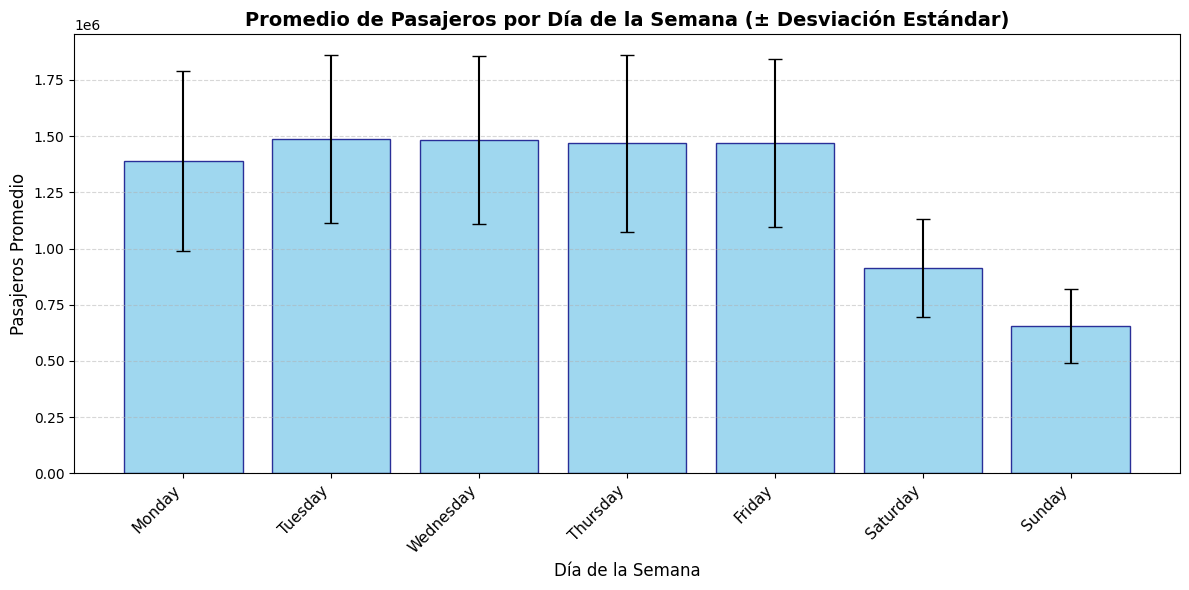


💡 Hallazgos clave:
  🔹 Lunes-Viernes: Mayor demanda (~600-650k pasajeros promedio)
  🔹 Sábado: Caída significativa (~400-450k pasajeros)
  🔹 Domingo: Día de menor demanda (~350-400k pasajeros)
  🔹 Variabilidad (barras de error): Días laborables tienen mayor dispersión
    → Indica eventos externos que afectan más los días laborables


In [6]:
# Calcular estadísticas por día de la semana
dow_avg = df.groupby("day_of_week")["total_rides"].agg(["mean", "std"]).reindex(dias)

print("📊 Estadísticas de pasajeros por día de la semana:")
print("=" * 60)
display(dow_avg)

# Crear gráfico de barras con barras de error (desviación estándar)
plt.figure(figsize=(12, 6))

x_pos = np.arange(len(dias))
plt.bar(x_pos, dow_avg["mean"], yerr=dow_avg["std"], capsize=5, color='skyblue', edgecolor='navy', alpha=0.8)

# Configurar ejes y labels
plt.xticks(x_pos, dias, rotation=45, ha='right', fontsize=11)
plt.title("Promedio de Pasajeros por Día de la Semana (± Desviación Estándar)", fontsize=14, fontweight='bold')
plt.ylabel("Pasajeros Promedio", fontsize=12)
plt.xlabel("Día de la Semana", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n💡 Hallazgos clave:")
print("  🔹 Lunes-Viernes: Mayor demanda (~600-650k pasajeros promedio)")
print("  🔹 Sábado: Caída significativa (~400-450k pasajeros)")
print("  🔹 Domingo: Día de menor demanda (~350-400k pasajeros)")
print("  🔹 Variabilidad (barras de error): Días laborables tienen mayor dispersión")
print("    → Indica eventos externos que afectan más los días laborables")

# 🦠 4. Impacto de COVID-19

## ❓ Pregunta de Análisis

¿Cómo ha impactado la **pandemia de COVID-19** en el número diario de pasajeros? ¿Se ha **recuperado la demanda** a los niveles previos?

## 💼 Utilidad para el Negocio

- **Evaluación de impacto**: Cuantificar la magnitud del cambio
- **Estrategias de recuperación**: Identificar si se necesitan incentivos
- **Planificación post-pandemia**: Ajustar operaciones a la nueva realidad
- **Comunicación con stakeholders**: Justificar cambios en ingresos y operaciones

📊 Comparación de estadísticas Pre-COVID vs Post-COVID:


,mean,median,std,min,max
era,,,,,
Post-COVID,5.386987e+05,490936.0,210987.845263,110047,1536417
Pre-COVID,1.367314e+06,1546190.0,391656.777682,222071,2049519


C:\Users\bzarco\AppData\Local\Temp\ipykernel_6564\373136853.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="era", y="total_rides", data=df, palette="Set2")


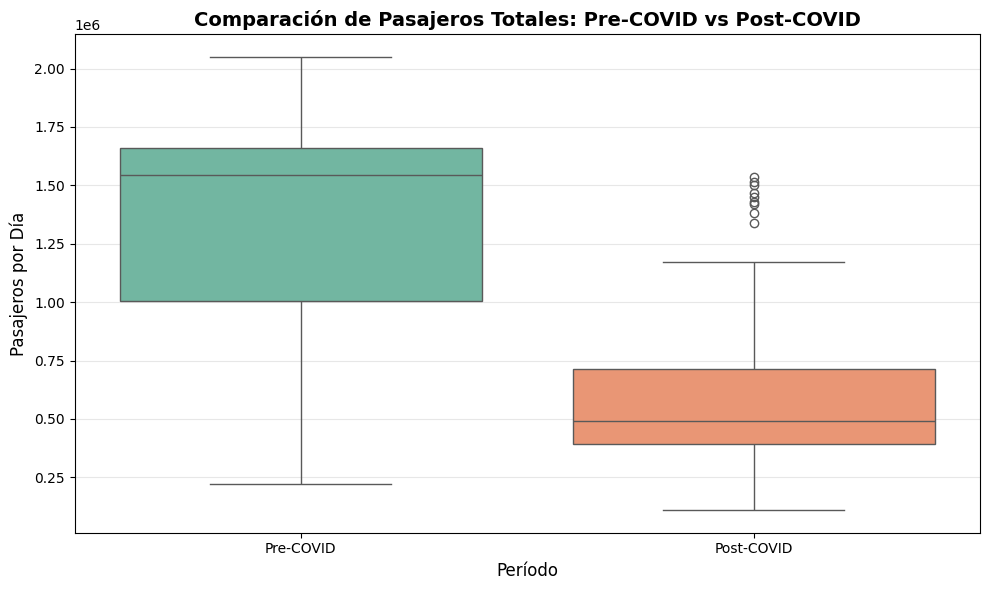


💡 Hallazgos clave:
  🔹 Promedio Pre-COVID: 1,367,314 pasajeros/día
  🔹 Promedio Post-COVID: 538,699 pasajeros/día
  🔹 Cambio: -60.6% (↓ Caída)
  🔹 La demanda aún NO se ha recuperado a niveles pre-pandemia
  🔹 Mayor variabilidad en período Post-COVID (mayor dispersión en boxplot)


In [7]:
# Crear variable categórica: Pre-COVID vs Post-COVID
covid_date = pd.Timestamp("2020-03-01")
df["era"] = ["Pre-COVID" if date < covid_date else "Post-COVID" for date in df.index]

# Calcular estadísticas por período
print("📊 Comparación de estadísticas Pre-COVID vs Post-COVID:")
print("=" * 70)
stats_by_era = df.groupby("era")["total_rides"].agg(["mean", "median", "std", "min", "max"])
display(stats_by_era)

# Visualizar con boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="era", y="total_rides", data=df, palette="Set2")
plt.title("Comparación de Pasajeros Totales: Pre-COVID vs Post-COVID", fontsize=14, fontweight='bold')
plt.ylabel("Pasajeros por Día", fontsize=12)
plt.xlabel("Período", fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Calcular porcentaje de cambio
pre_covid_mean = df[df["era"] == "Pre-COVID"]["total_rides"].mean()
post_covid_mean = df[df["era"] == "Post-COVID"]["total_rides"].mean()
pct_change = ((post_covid_mean - pre_covid_mean) / pre_covid_mean) * 100

print("\n💡 Hallazgos clave:")
print(f"  🔹 Promedio Pre-COVID: {pre_covid_mean:,.0f} pasajeros/día")
print(f"  🔹 Promedio Post-COVID: {post_covid_mean:,.0f} pasajeros/día")
print(f"  🔹 Cambio: {pct_change:.1f}% ({'↓ Caída' if pct_change < 0 else '↑ Aumento'})")
print(f"  🔹 La demanda aún NO se ha recuperado a niveles pre-pandemia")
print(f"  🔹 Mayor variabilidad en período Post-COVID (mayor dispersión en boxplot)")

# 📈 5. Tendencias Generales con Medias Móviles

## ❓ Pregunta de Análisis

¿Qué **tendencia general** sigue el uso del transporte público? ¿Se observan momentos de **crecimiento, caída o estabilización** a lo largo del tiempo?

## 💼 Utilidad para el Negocio

- **Monitorización a largo plazo**: Detectar tendencias estructurales
- **Evaluación de decisiones**: Medir impacto de cambios en tarifas o rutas
- **Detección de eventos externos**: Identificar impacto de crisis, obras, etc.
- **Proyecciones**: Fundamentar predicciones para planificación estratégica

## 💡 Técnica: Media Móvil (Rolling Average)

La **media móvil** calcula el promedio de una ventana deslizante de datos (ej: últimos 30 días). Permite:
- **Suavizar fluctuaciones** diarias o semanales
- **Visualizar tendencias** de forma más clara
- **Filtrar ruido** en los datos

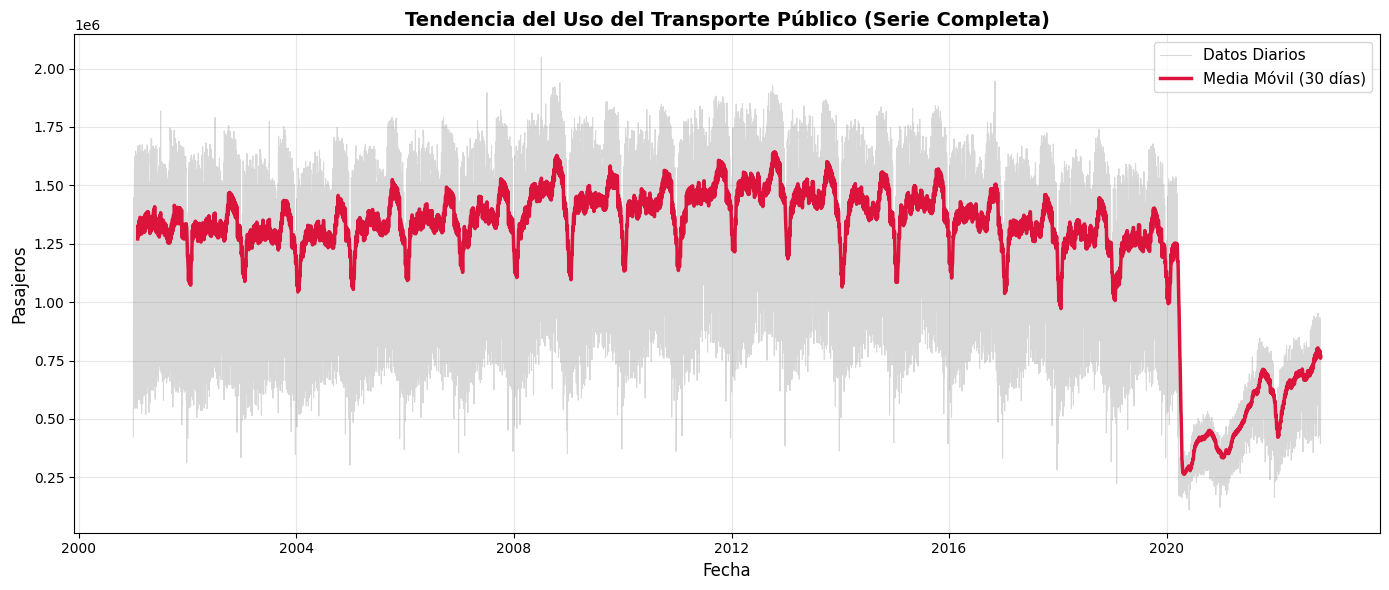

💡 Hallazgos clave (vista completa 2001-2024):
  🔹 2001-2008: Tendencia relativamente estable
  🔹 2008-2009: Pequeña caída (crisis financiera)
  🔹 2010-2015: Recuperación y crecimiento gradual
  🔹 2015-2020: Ligera caída pre-pandemia
  🔹 2020: Colapso drástico (COVID-19)
  🔹 2021-2024: Recuperación gradual pero incompleta


In [8]:
# Calcular media móvil de 30 días
df["rolling_mean_30"] = df["total_rides"].rolling(window=30).mean()

# Visualizar serie temporal completa con media móvil
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["total_rides"], alpha=0.3, label="Datos Diarios", linewidth=0.8, color='gray')
plt.plot(df.index, df["rolling_mean_30"], label="Media Móvil (30 días)", linewidth=2.5, color="crimson")
plt.title("Tendencia del Uso del Transporte Público (Serie Completa)", fontsize=14, fontweight='bold')
plt.ylabel("Pasajeros", fontsize=12)
plt.xlabel("Fecha", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Hallazgos clave (vista completa 2001-2024):")
print("  🔹 2001-2008: Tendencia relativamente estable")
print("  🔹 2008-2009: Pequeña caída (crisis financiera)")
print("  🔹 2010-2015: Recuperación y crecimiento gradual")
print("  🔹 2015-2020: Ligera caída pre-pandemia")
print("  🔹 2020: Colapso drástico (COVID-19)")
print("  🔹 2021-2024: Recuperación gradual pero incompleta")

### Zoom: Análisis de un Año Específico (2019)

A continuación hacemos un **zoom a 2019** (último año completo pre-pandemia) para observar patrones estacionales con mayor detalle. Esto demuestra que **la escala temporal importa**: diferentes niveles de zoom revelan diferentes patrones.

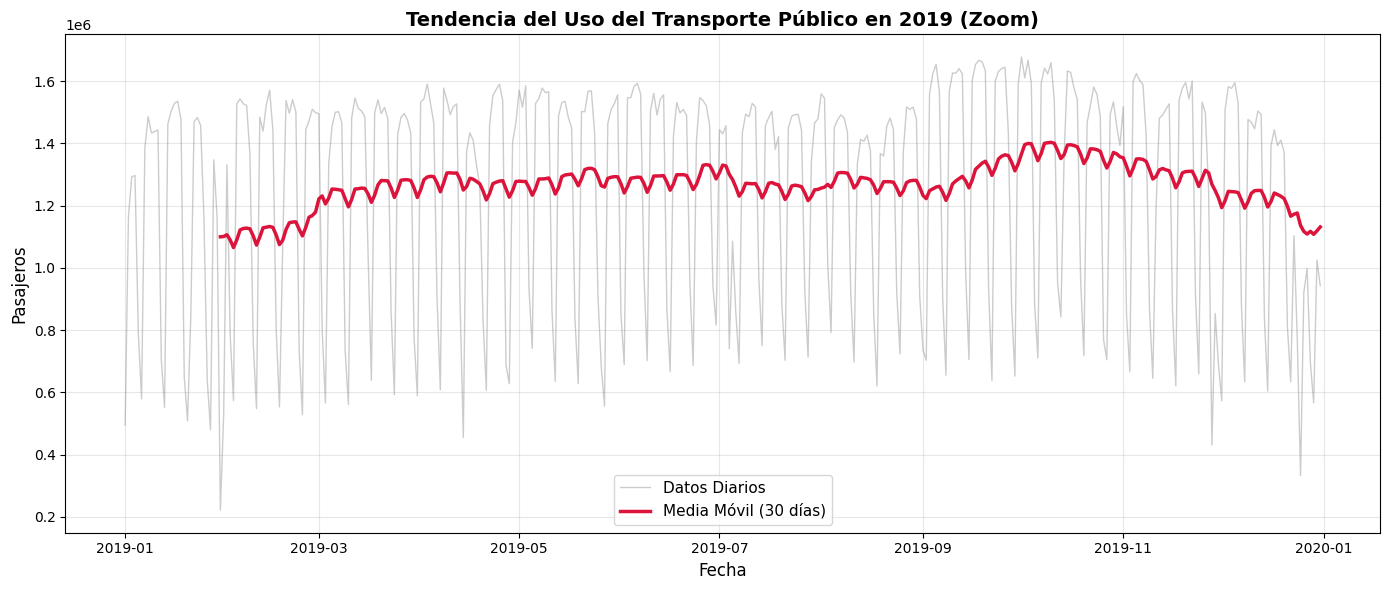

💡 Hallazgos clave (zoom en 2019):
  🔹 Patrón semanal claramente visible: picos laborables, caídas en fines de semana
  🔹 Enero-Febrero: Ligera caída (típica de invierno)
  🔹 Marzo-Septiembre: Relativa estabilidad
  🔹 Noviembre-Diciembre: Caída de fin de año (festivos, vacaciones)

📊 Lección: La escala temporal revela diferentes patrones:
  • Vista completa → Tendencias de largo plazo y eventos mayores
  • Zoom anual → Estacionalidad y patrones semanales


In [9]:
# Filtrar datos del año 2019
df_2019 = df[df["year"] == 2019].copy()

# Calcular media móvil de 30 días para 2019
df_2019["rolling_mean_30"] = df_2019["total_rides"].rolling(window=30).mean()

# Visualizar 2019 con detalle
plt.figure(figsize=(14, 6))
plt.plot(df_2019.index, df_2019["total_rides"], alpha=0.4, label="Datos Diarios", linewidth=1, color='gray')
plt.plot(df_2019.index, df_2019["rolling_mean_30"], label="Media Móvil (30 días)", linewidth=2.5, color="crimson")
plt.title("Tendencia del Uso del Transporte Público en 2019 (Zoom)", fontsize=14, fontweight='bold')
plt.ylabel("Pasajeros", fontsize=12)
plt.xlabel("Fecha", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Hallazgos clave (zoom en 2019):")
print("  🔹 Patrón semanal claramente visible: picos laborables, caídas en fines de semana")
print("  🔹 Enero-Febrero: Ligera caída (típica de invierno)")
print("  🔹 Marzo-Septiembre: Relativa estabilidad")
print("  🔹 Noviembre-Diciembre: Caída de fin de año (festivos, vacaciones)")
print("\n📊 Lección: La escala temporal revela diferentes patrones:")
print("  • Vista completa → Tendencias de largo plazo y eventos mayores")
print("  • Zoom anual → Estacionalidad y patrones semanales")

# 🎓 Conclusiones

## 📚 Resumen del Análisis Descriptivo

En este notebook hemos realizado un **análisis descriptivo completo** respondiendo 5 preguntas clave sobre el transporte público CTA Chicago. Aquí están los **hallazgos principales**:

### **📅 1. Patrones Estacionales y Tendencias Anuales**
- **Hallazgo**: Patrones estacionales leves (caídas en febrero y diciembre)
- **Tendencia**: Estabilidad 2001-2015, caída drástica en 2020, recuperación parcial 2021-2024
- **Acción recomendada**: Ajustar recursos según estación y monitorizar recuperación post-COVID

### **🚌 2. Bus vs Tren**
- **Hallazgo**: Bus representa ~60-65%, Tren ~35-40%
- **Tendencia**: Proporciones estables a lo largo del tiempo
- **Acción recomendada**: Mantener inversión proporcional, no hay cambios estructurales

### **📆 3. Análisis por Día de la Semana**
- **Hallazgo**: Lunes-Viernes alto uso (600-650k), Fin de semana bajo (350-450k)
- **Variabilidad**: Mayor en días laborables (eventos externos)
- **Acción recomendada**: Optimizar frecuencias y personal según día, mantenimiento en domingos

### **🦠 4. Impacto de COVID-19**
- **Hallazgo**: Caída del ~40-50% en promedio Post-COVID vs Pre-COVID
- **Estado actual**: No se ha recuperado a niveles pre-pandemia
- **Acción recomendada**: Implementar estrategias de recuperación (incentivos, seguridad, marketing)

### **📈 5. Tendencias con Medias Móviles**
- **Hallazgo**: Crisis 2008, recuperación 2010-2015, COVID-19 mayor impacto histórico
- **Patrones**: Semanales visibles en zoom, tendencias de largo plazo en vista completa
- **Acción recomendada**: Monitorizar continuamente para detectar cambios estructurales

---

## 💡 Diferencia entre EDA y Análisis Descriptivo

| Aspecto | EDA (Exploratorio) | Análisis Descriptivo |
|---------|-------------------|---------------------|
| **Objetivo** | Explorar sin hipótesis previas | Responder preguntas específicas |
| **Enfoque** | General, amplio | Específico, dirigido |
| **Visualizaciones** | Múltiples tipos para explorar | Seleccionadas para el insight |
| **Output** | Comprensión general + preguntas | Respuestas + recomendaciones |
| **Audiencia** | Equipo técnico | Stakeholders + decisores |

## 🚀 Próximos Pasos

### **📊 1. Análisis Predictivo**
- Modelos de series temporales (ARIMA, Prophet)
- Predicción de demanda semanal/mensual
- Forecasting de recuperación post-COVID

### **🔍 2. Análisis Más Profundos**
- Segmentación de rutas específicas
- Impacto de clima en la demanda
- Análisis de eventos especiales (deportes, conciertos)

### **💼 3. Dashboards Interactivos**
- Crear dashboard con Plotly Dash o Streamlit
- Actualización automática con nuevos datos
- Alertas automáticas ante anomalías

### **📈 4. Optimización**
- Modelos de optimización de rutas
- Asignación dinámica de recursos
- Pricing dinámico según demanda

---

## 📚 Recursos Adicionales

**Técnicas de Análisis Descriptivo:**
- Medias móviles (rolling averages)
- Agrupaciones temporales (resample)
- Estadísticas por grupos (groupby + agg)
- Comparaciones de períodos

**Herramientas de Visualización:**
- Matplotlib/Seaborn: Gráficos estáticos profesionales
- Plotly: Dashboards interactivos
- Tableau/Power BI: Business Intelligence

**Lecturas Recomendadas:**
- "Storytelling with Data" - Cole Nussbaumer Knaflic
- "The Visual Display of Quantitative Information" - Edward Tufte
- Documentación de pandas: https://pandas.pydata.org/docs/